In [ ]:
### se cargas los paquetes.
import pandas as pd  ## cargar conjuntos de datos
import numpy as np ## manejo de vectores y matrices
import scipy as scp ## estadisticas
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt  ## graficas
import seaborn as sns  ## graficos en panel

#http://127.0.0.1:17505/library/FactoMineR/html/milk.html

## Práctica 1: datos milk

En esta práctica se desea trabajar con el conjunto de datos "milk.txt", el cuál esta compuesto por 85 muestras y 6 variables cuantitativas. Las variables son: densidad (density), grasa (fat), proteína, caseína (casein), secado (dry) y rendimiento (yield). En este conjunto se quiere estimar el rendimiento en función de las demás variables, por esta razón es importante estudiar la correlación lineal y luego realizar un modelo.

In [ ]:
milk=pd.read_csv('milk.txt',sep='\s+')
print(milk)

    density        fat    protein     casein         dry  yield
1     1.032  37.700001  35.700001  28.500000  127.099998  15.35
2     1.032  37.500000  35.299999  28.000000  128.699997  14.72
3     1.031  37.000000  32.799999  25.299999  124.099998  14.61
4     1.031  39.500000  33.700001  26.799999  127.500000  14.56
5     1.031  36.000000  32.799999  25.900000  121.599998  13.74
..      ...        ...        ...        ...         ...    ...
81    1.031  37.599998  33.200001  26.299999  125.599998  14.94
82    1.030  36.099998  33.599998  26.200001  125.300003  14.43
83    1.030  34.099998  33.200001  26.000000  124.199997  14.37
84    1.031  39.000000  32.299999  25.400000  123.500000  14.40
85    1.030  34.400002  33.099998  26.500000  123.500000  14.18

[85 rows x 6 columns]


## Diagrama de dispersión

Realice un diagrama de dispersión del rendimiento (eje y) vs densidad (eje x). Además agregue la correlación entre las variables.

Text(0, 0.5, 'yield')

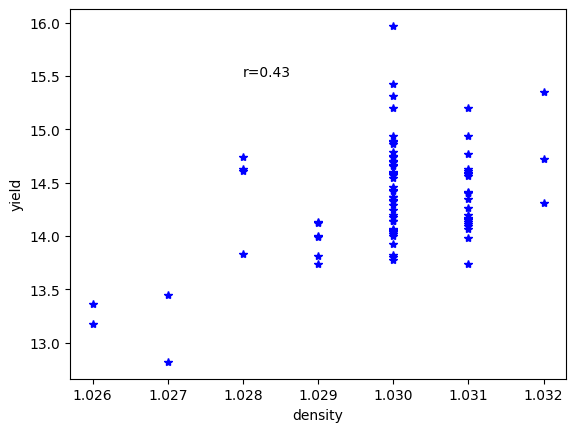

In [ ]:
plt.plot(milk['density'],milk['yield'],'*',color='blue')
plt.text(1.028,15.5,'r=0.43')
plt.xlabel('density')
plt.ylabel('yield')

Realice un diagrama de dispersión del rendimiento (eje y) vs grasa (eje x). Además agregue la correlación entre las variables.

Text(0, 0.5, 'yield')

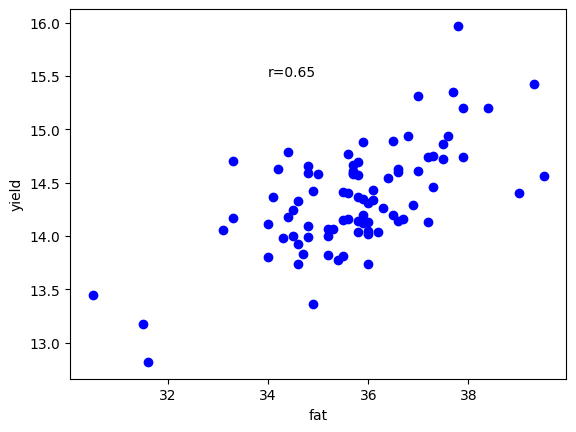

In [ ]:
plt.plot(milk['fat'],milk['yield'],'o',color='blue')
plt.text(34,15.5,'r=0.65')
plt.xlabel('fat')
plt.ylabel('yield')

Realice un diagrama de dispersión del rendimiento (eje y) vs proteína (eje x). Además agregue la correlación entre las variables.

Text(0, 0.5, 'yield')

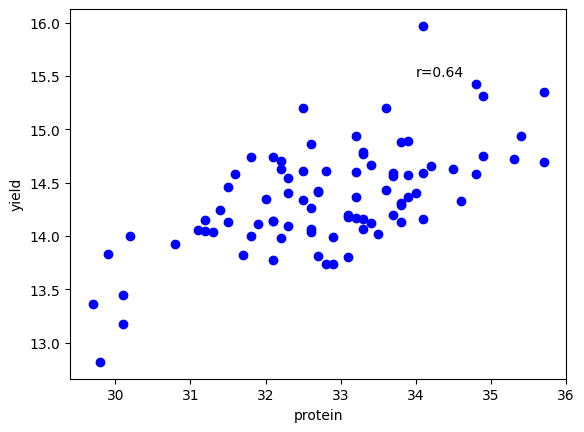

In [ ]:
plt.plot(milk['protein'],milk['yield'],'o',color='blue')
plt.text(34,15.5,'r=0.64')
plt.xlabel('protein')
plt.ylabel('yield')

Realice un diagrama de dispersión del rendimiento (eje y) vs caseína(eje x). Además agregue la correlación entre las variables.

Text(0, 0.5, 'yield')

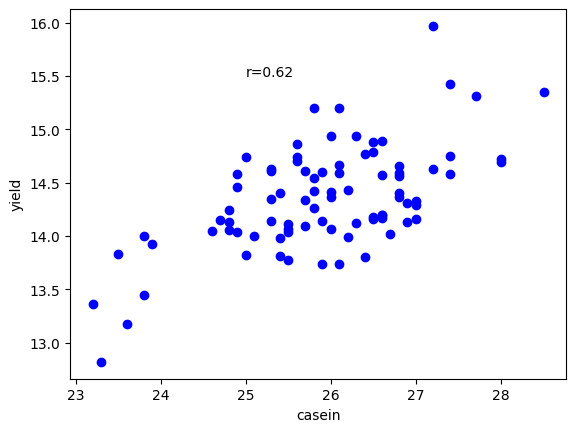

In [ ]:
plt.plot(milk['casein'],milk['yield'],'o',color='blue')
plt.text(25,15.5,'r=0.62')
plt.xlabel('casein')
plt.ylabel('yield')

Realice un diagrama de dispersión del rendimiento (eje y) vs secado (eje x). Además agregue la correlación entre las variables.

Text(0, 0.5, 'yield')

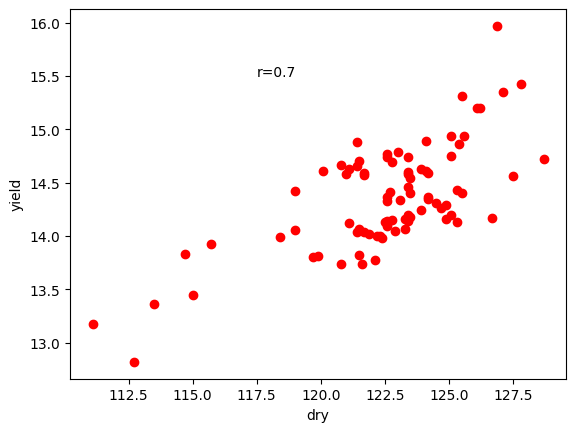

In [ ]:
plt.plot(milk['dry'],milk['yield'],'o',color='r')
plt.text(117.5,15.5,'r=0.7')
plt.xlabel('dry')
plt.ylabel('yield')

## Matriz de correlación con pandas

In [ ]:
### estadisticas descriptivas de los datos
milk.describe()



,density,fat,protein,casein,dry,yield
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,1.030024,35.724706,32.844706,25.909412,122.563529,14.356824
std,0.001134,1.564175,1.353435,1.077654,3.181451,0.493634
min,1.026000,30.500000,29.700001,23.200001,111.099998,12.820000
25%,1.030000,34.799999,32.099998,25.299999,121.500000,14.070000
50%,1.030000,35.799999,32.900002,26.000000,122.800003,14.340000
75%,1.031000,36.599998,33.799999,26.600000,124.199997,14.630000
max,1.032000,39.500000,35.700001,28.500000,128.699997,15.970000


In [ ]:
## Genera la matriz de correlación entre todas las variables
corr_df = milk.corr()
print("The correlation DataFrame is:")
print(corr_df, "\n")

The correlation DataFrame is:
          density       fat   protein    casein       dry     yield
density  1.000000  0.402486  0.543212  0.596185  0.753481  0.432412
fat      0.402486  1.000000  0.446137  0.429893  0.683415  0.651501
protein  0.543212  0.446137  1.000000  0.958432  0.667631  0.641068
casein   0.596185  0.429893  0.958432  1.000000  0.695393  0.617443
dry      0.753481  0.683415  0.667631  0.695393  1.000000  0.699836
yield    0.432412  0.651501  0.641068  0.617443  0.699836  1.000000 



## Mapa de correlaciones con seaborn

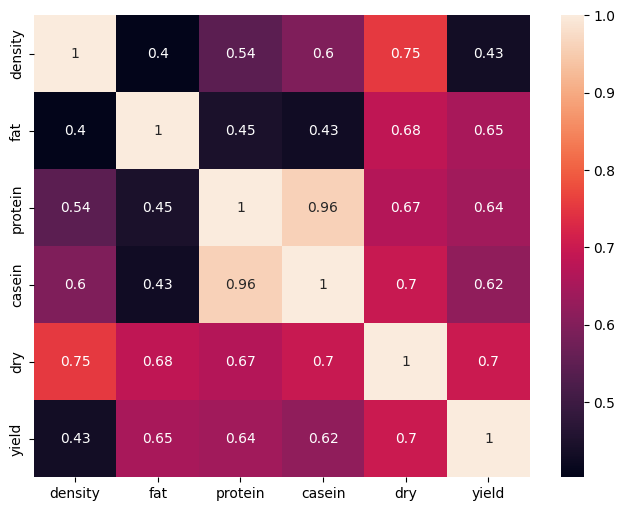

In [ ]:
## Mapa de las correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True)
plt.show()

## Modelo de regresión lineal múltiple

Realice el siguiente modelo:

$yield= density+fat+protein+casein+dry$

Observe si los coeficientes son significativos, si hay alguno que no, entonces quite la variable asociada a ese coeficiente.

In [ ]:
X = milk[['density', 'fat', 'protein','casein','dry']]
y = milk['yield']
X = sm.add_constant(X, prepend=True) ## se el agrega el intercepto
modelo = sm.OLS(endog=y, exog=X) ## OLS minimo cuadrados ordinarios
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  yield   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     25.31
Date:                Fri, 22 Sep 2023   Prob (F-statistic):           3.81e-15
Time:                        20:42:02   Log-Likelihood:                -19.460
No. Observations:                  85   AIC:                             50.92
Df Residuals:                      79   BIC:                             65.58
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         74.0266     48.229      1.535      0.1

## Selección de variables

Realice el siguiente modelo:

quitando la variable no significativa. Este proceso se repite hasta obtener un modelo con las todas las variables significativas. Dicho proceso que se esta utilizando particularmente se llama selección hacia atras (backward)

In [ ]:
X = milk[['fat', 'protein','dry']]
y = milk['yield']
X = sm.add_constant(X, prepend=True) ## se el agrega el intercepto
modelo = sm.OLS(endog=y, exog=X) ## OLS minimo cuadrados ordinarios
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  yield   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     40.96
Date:                Sat, 18 Sep 2021   Prob (F-statistic):           3.30e-16
Time:                        13:53:02   Log-Likelihood:                -20.870
No. Observations:                  85   AIC:                             49.74
Df Residuals:                      81   BIC:                             59.51
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8475      1.344      1.374      0.1

/home/andres.ochoa/.local/lib/python3.8/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


## Supuesto de normalidad en los errores

Es importante analizar si se cumple o no el supuesto normalidad en los errores. Para ello se recomiendan en primer lugar, los gráficos histograma o diagrama de cajas de los residuales $\varepsilon$ del modelo. Posteriormente se recomienda el uso de pruebas como: shapiro wilks (muestras menores que 50), anderson darling, jarque-bera, etc

(array([ 6., 12., 22.,  9., 14., 15.,  5.,  1.,  0.,  1.]),
 array([-0.60148862, -0.43384609, -0.26620355, -0.09856102,  0.06908151,
         0.23672404,  0.40436657,  0.5720091 ,  0.73965164,  0.90729417,
         1.0749367 ]),
 <BarContainer object of 10 artists>)

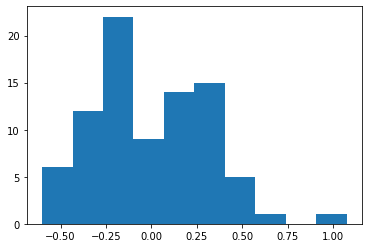

In [ ]:
predicciones = modelo.predict(exog = X)
residuales = milk['yield']- predicciones
plt.hist(residuales)

/home/andres.ochoa/.local/lib/python3.8/site-packages/statsmodels/graphics/gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


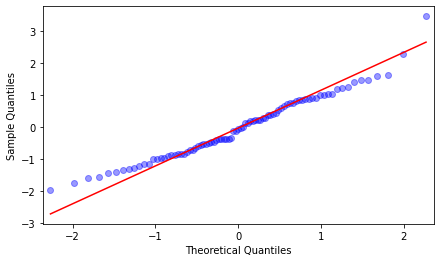

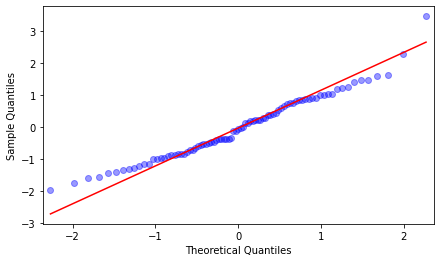

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
sm.qqplot(
    residuales,
    fit   = True,
    line  = 'q',
    alpha = 0.4,
    lw    = 2,
    ax    = ax
)

## Prueba Shapiro Wilks



In [ ]:
shapiro_test = stats.shapiro(residuales)
shapiro_test

ShapiroResult(statistic=0.9739896059036255, pvalue=0.08318730443716049)

R/ - Con base el pvalor se observa que no rechaza Ho (Hipotesis de normalidad), por lo cual se dice que los residuales cumplen el supuesto.